In [224]:
#pip install sentence-transformers
#!pip install groq

# IMPORTING LIBRARIES

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from groq import Groq
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [234]:
#client = Groq(api_key="-----------------------------------------")

# COPYING THE DATA

In [4]:
df1 = pd.read_csv("Data/comment.csv")
df2 = pd.read_csv("Data/fraud_email.csv")
df3 = pd.read_csv("Data/sms_spam.csv")

In [5]:
df2 = df2[['Text', 'Class']]

# CHECKING FOR NULL VALUES

In [6]:
df1.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [7]:
df2.isnull().sum()

Text      1
Class    29
dtype: int64

# DELETING NULL VALUES

In [8]:
df2 = df2.dropna()

In [9]:
df2.isnull().sum()

Text     0
Class    0
dtype: int64

# CLEANING ROWS

In [10]:
df2['Class'].unique()

array(['0', '1',
       ' I will like you to provide immediately your full names and address so that the Attorney will prepare the necessary documents and affidavits'],
      dtype=object)

In [11]:
df2 = df2[df2["Class"].isin(['0', '1'])]

In [12]:
df2['Class'].unique()

array(['0', '1'], dtype=object)

In [13]:
df2['Class'] = df2['Class'].astype(int)
df2['Class'].unique()

array([0, 1])

In [14]:
df3.isnull().sum()

label      0
message    0
dtype: int64

In [15]:
df3['label'].unique()

array(['ham', 'spam'], dtype=object)

# ADDING A NEW COLUMN WHICH TAGS THE TEXT AS 1 WHEN ANY OF THE COLUMNS IS 1

In [16]:
df1['label'] = df1[[
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]].max(axis=1)

In [17]:
df1_clean = df1[['comment_text', 'label']].copy()
df1_clean.columns = ['text', 'label']

df1_clean['domain'] = 'comment'

In [18]:
df1.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,label
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0


# BALANCING THE DATASETS

In [19]:
df1_safe = df1_clean[df1_clean['label'] == 0]
df1_harm = df1_clean[df1_clean['label'] == 1]

In [20]:
# sample to reduce dominance
df1_safe_sample = df1_safe.sample(n=747, random_state=42)
df1_harm_sample = df1_harm.sample(n=747, random_state=42)

In [21]:
df1_balanced = pd.concat([df1_safe_sample, df1_harm_sample])

In [22]:
df1_balanced.head()

,text,label,domain
46733,"""\n\nOh, don't worry about me, Sandstein. I'm ...",0,comment
110326,Are you trying to dispute that fact?,0,comment
76687,SWOT analysis \n\nThis source – Align Technolo...,0,comment
36231,"cover \n\nso, do we want a current or older co...",0,comment
21514,P.S. It's probably worth setting up a template...,0,comment


In [23]:
df1_balanced['label'].unique()

array([0, 1], dtype=int64)

In [24]:
df2_clean = df2.copy()
df2_clean.columns = ['text', 'label']
df2_clean['domain'] = 'email'

In [25]:
df2_safe = df2_clean[df2_clean['label'] == 0]
df2_harm = df2_clean[df2_clean['label'] == 1]

In [26]:
min_size = 747

In [27]:
df2_balanced = pd.concat([
    df2_safe.sample(min_size, random_state=42),
    df2_harm.sample(min_size, random_state=42)
])

In [28]:
len(df2_balanced)

1494

In [29]:
df2_balanced.head()

,text,label,domain
373,FYI --Reid: Shelby Has Hold On All NomineesFri...,0,email
6002,FYI —POLITICOBoehner chief of staff dies at 46...,0,email
4708,This draft sounds didactic. That's ok in terms...,0,email
834,w000 hoo!,0,email
11465,Will do.,0,email


In [30]:
len(df2_balanced[df2_balanced['label']==0])

747

In [31]:
len(df1_balanced[df1_balanced['label']==1])

747

In [32]:
df3_clean = df3.copy()
df3_clean.columns = ['label', 'text']

df3_clean['domain'] = 'sms'

In [33]:
df3_clean['label'] = df3_clean['label'].map({
    'ham': 0,
    'spam': 1
})

In [34]:
df3_safe = df3_clean[df3_clean['label'] == 0]
df3_harm = df3_clean[df3_clean['label'] == 1]

min_size = min(len(df3_safe), len(df3_harm))

In [35]:
df3_balanced = pd.concat([
    df3_safe.sample(min_size, random_state=42),
    df3_harm.sample(min_size, random_state=42)
])

In [36]:
len(df3_balanced[df3_balanced['label']==0])

747

In [37]:
final_df = pd.concat([
    df1_balanced,
    df2_balanced,
    df3_balanced
], ignore_index=True)

# ADDING SYNTHETIC DATA

In [38]:
safe_conflict_examples = [

    "I disagree with your point.",

    "Your argument is weak but valid.",

    "I strongly disagree with this idea.",

    "This policy is terrible.",

    "I don't think that's correct.",

    "I understand your perspective but disagree.",

    "Your reasoning makes no sense to me.",

    "I don't support this decision.",

    "This is a bad proposal.",

    "I think your conclusion is wrong."
]

synthetic_df = pd.DataFrame({

    "text": safe_conflict_examples,

    "label": [0] * len(safe_conflict_examples),

    "domain": ["synthetic"] * len(safe_conflict_examples)
})

In [39]:
synthetic_df = pd.concat(
    [synthetic_df] * 50,
    ignore_index=True
)

In [40]:
final_df = pd.concat(
    [final_df, synthetic_df],
    ignore_index=True
)

In [41]:
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [42]:
print(final_df['label'].value_counts())
print(final_df['domain'].value_counts())

label
0    2741
1    2241
Name: count, dtype: int64
domain
comment      1494
sms          1494
email        1494
synthetic     500
Name: count, dtype: int64


In [43]:
df = final_df.copy()

In [44]:
df.head()

,text,label,domain
0,Yeah its me \n\nYou're telling me not to write...,1,comment
1,Bring it if you got it,0,sms
2,This is your final warning if you persist in v...,1,comment
3,I will be out of the office Monday October 12 ...,0,email
4,"Pathetic little fucks, it's called a penis fil...",1,comment


In [45]:
df['label'] = df['label'].astype(int)
df['text'] = df['text'].fillna("")

# SPLITTING THE DATASET

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

# ENCODING

In [47]:
X_train_vec = embedder.encode(
    X_train.tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

X_test_vec = embedder.encode(
    X_test.tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

# TRAINING

In [48]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=2000)

# EVALUATING

In [49]:
y_prob = model.predict_proba(X_test_vec)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9579918032786885


In [50]:
y_risk_scores = model.predict_proba(X_test_vec)[:, 1]

In [51]:
threshold = 0.5

y_pred = (y_risk_scores >= threshold).astype(int)

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       549
           1       0.89      0.84      0.86       448

    accuracy                           0.88       997
   macro avg       0.88      0.88      0.88       997
weighted avg       0.88      0.88      0.88       997



In [53]:
def predict_risk(text):
    vec = embedder.encode([text], normalize_embeddings=True)
    score = model.predict_proba(vec)[0][1]
    
    return score

In [54]:
texts = X_test[:5]

for t in texts:
    score = predict_risk(t)
    print(t, "→", score)

Your reasoning makes no sense to me. → 0.05931450347777969
fixed.speaking with Paul - just blind copied you on something re: global health.otherwise rest will keep.cdm → 0.09744169036402296
"

 Please do not add unsourced content, as you did to I Should Have Known Better. This contravenes Wikipedia's policy on verifiability. If you continue to do so, you may be blocked from editing Wikipedia.   talktalk " → 0.37424695926450463
Dallas 

Thanks for deigning to talk to a vandal you diagnosed after one small edit which included three WP:RSs. Referees give penalties, not linesmen. Witness Dougie McDonald and Steven Craven. 94.14.244.0 → 0.19550682449944842
Fyi → 0.0551295414766392


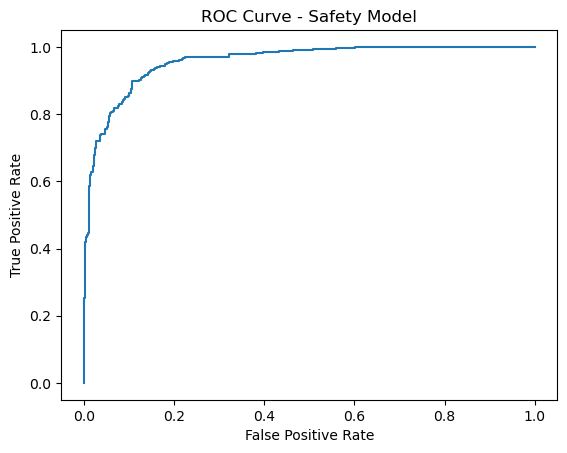

In [55]:
fpr, tpr, thresholds = roc_curve(y_test, y_risk_scores)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Safety Model")
plt.show()

In [56]:
def visualize_risk(score, threshold=0.5):

    plt.figure(figsize=(8, 1.5))

    plt.barh(
        ['Risk'],
        [score]
    )

    plt.axvline(
        threshold,
        linestyle='--'
    )

    plt.xlim(0, 1)

    plt.xlabel("Risk Score")
    plt.title("Safety Risk Assessment")

    plt.show()

# VISUALIZING THE RESULT

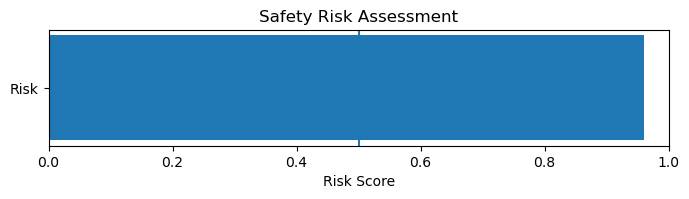

In [57]:
score = predict_risk(
    "Verify your bank account immediately."
)

visualize_risk(score)

# PROMPTING THE LLM TO INTERPRET THE RESULT

In [229]:
def explain_risk(text, risk_score):

    prompt = f"""
You are a Trust & Safety analyst assistant.

A message has been analyzed by a safety classifier.

Message:
{text}

Risk score:
{risk_score:.2f}

Provide:
- Key risk indicators
- Possible abuse category
- Suggested moderation action

Use concise bullet points.
"""

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.choices[0].message.content

In [230]:
text = "Verify your bank account immediately."

score = predict_risk(text)

analysis = explain_risk(text, score)

print(analysis)

Based on the provided data, here's the breakdown:

**Key Risk Indicators:**

* High urgency (immediate action required)
* Potential for financial loss or phishing
* Lack of personalization or contextual information

**Possible Abuse Category:**

* Phishing or scam promotion
* Financial exploitation or identity theft

**Suggested Moderation Action:**

* Flag the message for review
* Remove the message to prevent further engagement
* Recommend a more informative and contextual message that clarifies the purpose and authenticity of the request.


# SAVING THE MODEL AND EMBEDDINGS

In [59]:

joblib.dump(model, "SafetyModel/classifier.pkl")
joblib.dump(embedder, "SafetyModel/embedder.pkl")

print("Model saved.")

Model saved.
